# A1 — anchor / idle-capital allocator study

Pre-registration: [README.md](README.md) (hypothesis, KILL rules, fixed allocator rules,
priors — written before any computation). Write-up: [findings.md](findings.md).
Approximations: [results/panel_notes.md](results/panel_notes.md).

Pipeline (each cell re-runs a script; the panel build reads prod.db read-only and takes ~15 s):

1. `build_panel.py` → `results/daily_panel.csv` — one unit-exposure daily return column per sleeve.
2. `run.py` → `results/summary.csv`, `results/equity_*.csv`, `results/verdict.json` — variants,
   sensitivity cells, diagnostics, and the pre-registered verdict.


## 1. Build the daily unit-exposure panel

In [1]:
%run build_panel.py

# Panel notes — A1 anchor allocator study

*Generated by `build_panel.py` on 2026-09-07 04:42 UTC. Every approximation in the panel is listed here with the number that bounds it.*

## Build log



- J+ loop: 2563 days 2019-09-02 → 2026-09-07 in 7.5s (`_run_decision_loop`, calendar = cd_spot_binance daily).
- Period: 2020-01-01 → 2026-09-06 (latest full day = last date before today UTC with 24 spot bars). In-period dates with < 24 spot bars: none.
- Panel rows: 2441 calendar days; days missing from the J+ calendar inside the period: 0 [].
- `aux_btc_30d` = compounded trailing 30-day spot return through T−1 (no same-day look-ahead). Share of days > +5 %: 42.4 %, < −10 %: 20.0 %, > +10 %: 32.7 %.
- EMA 1W BTC: `ema_p × btc_daily`; 14 position changes in-period, each charged 15 bp (a change 0→±1, ±1→∓1 or ±1→0 counts once). Days with ema_p = 0 (flat): 74; long 1408, short 959.


- ETH: 3,512,997 eth_1m rows streamed from 2019-12-31 → 58,558 hourly buckets, 2,442 days (same first-open/last-close aggregation as `data/loaders.py`).
- ETH daily: rebuilt full-period from `eth_1m` (1 in-period days without an ETH return, set to 0). Parity vs the loop's `eth_daily_pct` on 1088 overlapping days from 2023-09-15: max |diff| = 1.39e-17.
- eth_daily: 1× ETH on days with mode ∈ ('strong_bull', 'mild_bull') (280 days, 45 regime entries); 15 bp on the entry day and 15 bp on the last day of each bull segment (the exit fill happens at the next open, booked on the last held day so inactive days stay exactly 0). Mode counts in-period: {'uncertain': 1455, 'bear': 706, 'strong_bull': 243, 'mild_bull': 37}.
- r4_eth: rebuilt from full-period `eth_1m` with `r4math.r4_eth_returns`; parity vs the loop's `r4_eth_pct` on 71 fire days from 2023-09-15: max |diff| = 2.78e-17.
- r4_eth_v2: rebuilt from full-period `eth_1m` with `r4math.r4_eth_v2_returns`; parity vs the loop's `r4_eth_v2_pct

- ADX (harness T2 = production config; candles end 2026-09-06): 28 trades (16 long / 12 short, 1 still open) 2018-03-19 → 2026-08-21; harness ret +2392 %, maxDD -15.1 %, WR 57 %. Daily marks = dir × close-to-close (exit day uses the harness exit price, 10 bp charged). Parity: compounded marks vs harness gross return — longs max |dev| 3.77e-15 (exact); shorts 1.36e-01 (daily-rebalanced short ≠ fixed-notional short; expected, second order). In-period active days: 875. Funding-crowding LONG veto (config FUNDING_VETO_Z) is not in the harness — affects one known trade (2025-10-05).
- chento_btc: backward-only pool 211 rows (0 NaN r_outcome dropped) → OKX-alignment dropped 110, BTC-30d>+10 % short-skip dropped 11 → 90 trades 2021-01-29 → 2026-08-22; tilt skip_after_loss: 40 traded; Σ effective R +21.4. Return on notional per trade = size × r_outcome × risk/entry (mean risk/entry 2.31 %, mean +0.38 %, Σ +15.4 %), spread over the UTC days covered by [ts, ts+72h) in proportion to hours. Overlap

- GOLD: PAXG daily close (last hourly bar of the UTC day, 2201 days 2020-08-28 → 2026-09-06) close-to-close from 2020-08-28; before that GC=F (`macro_daily` GOLD, 241 in-period proxy days through 2020-08-28, 0 on non-trading days). PAXG total +124 %, ann. vol 18.7 %; proxy stretch total +29.3 %. PAXG days with |r| > 4 %: [('2020-11-09', -4.5, -5.0), ('2021-01-08', -4.3, -4.1), ('2024-04-13', 4.1, None), ('2025-10-16', 4.7, 2.5), ('2025-10-17', -4.5, -2.1), ('2025-10-21', -6.1, -5.7), ('2025-12-29', -4.1, -4.5), ('2026-01-28', 6.7, 4.4), ('2026-01-30', -10.1, -11.4), ('2026-02-05', -6.6, -1.2), ('2026-02-06', 5.2, 1.8), ('2026-03-03', -4.1, -3.5), ('2026-06-11', 4.0, -0.4), ('2026-08-05', 5.0, 3.7)] (PAXG %, GC=F % same day).
- cash: 4 %/365 per day, flat — an assumption (too high for 2020-21, about right 2023-26).
- aux_mode / aux_gated come from the J+ loop (regime classifier and R4 vol gate, both T−1).
- short_squeeze: OMITTED. `short_squeeze_sessions/strategy_backtest.ipynb` is a 51

## 2. Run the allocator variants + sensitivity + verdict

In [2]:
%run run.py

panel 2441 days 2020-01-01 → 2026-09-06



=== summary (full period 2020-01-01 → 2026-09-06) ===
                      variant  sharpe  cagr   mdd  calmar  ret_2022  sharpe_post_etf  mean_idle_pct  mean_anchor_pct  mean_gross  d_sharpe_vs_baseline  d_mdd_pp_vs_baseline
                     baseline   1.584 0.223 0.148   1.502     0.210            1.726         32.671           48.000       0.338                 0.000                 0.000
                baseline_gold   1.970 0.263 0.109   2.413     0.142            2.376         32.671           48.000       0.548                 0.386                -3.932
                     overflow   1.356 0.299 0.214   1.399     0.239            1.551         32.671           80.626       0.869                -0.228                 6.567
             overflow_no_gold   1.261 0.258 0.232   1.110     0.346            1.061         32.671           80.626       0.869                -0.323                 8.378
           overflow_cash_only   1.698 0.239 0.145   1.644     0.226            1

## 3. Verdict and summary table

In [3]:
import json
import pandas as pd
pd.set_option('display.width', 220)
v = json.load(open('results/verdict.json', encoding='utf-8'))
print('VERDICT:', v['verdict'], '| period', *v['period'], '| n_days', v['n_days'])
for k, c in v['clauses'].items():
    print(f"  {'FIRES' if c['fires'] else 'no   '}  {k}: measured {c['measured']:+.3f} vs {c['threshold']:+.2f}")
s = pd.read_csv('results/summary.csv')
cols = ['variant', 'group', 'sharpe', 'cagr', 'mdd', 'calmar', 'ret_2022', 'sharpe_post_etf',
        'mean_idle_pct', 'mean_anchor_pct', 'mean_gross', 'd_sharpe_vs_baseline', 'd_mdd_pp_vs_baseline']
display(s[cols].round(3))


VERDICT: KILL | period 2020-01-01 2026-09-06 | n_days 2441
  FIRES  KILL: Sharpe uplift < +0.10: measured -0.228 vs +0.10
  FIRES  KILL: MDD worse by > 5 pp: measured +6.567 vs +5.00
  FIRES  KILL: uplift disappears without gold (ΔSharpe_nogold < +0.10): measured -0.323 vs +0.10
  no     CONFIRM: Sharpe uplift ≥ +0.20: measured -0.228 vs +0.20
  no     CONFIRM: MDD ≤ baseline + 3 pp: measured +6.567 vs +3.00


,variant,group,sharpe,cagr,mdd,calmar,ret_2022,sharpe_post_etf,mean_idle_pct,mean_anchor_pct,mean_gross,d_sharpe_vs_baseline,d_mdd_pp_vs_baseline
0,baseline,core,1.584,0.223,0.148,1.502,0.210,1.726,32.671,48.000,0.338,0.000,0.000
1,baseline_gold,core,1.970,0.263,0.109,2.413,0.142,2.376,32.671,48.000,0.548,0.386,-3.932
2,overflow,core,1.356,0.299,0.214,1.399,0.239,1.551,32.671,80.626,0.869,-0.228,6.567
3,overflow_no_gold,core,1.261,0.258,0.232,1.110,0.346,1.061,32.671,80.626,0.869,-0.323,8.378
4,overflow_cash_only,core,1.698,0.239,0.145,1.644,0.226,1.858,32.671,80.670,0.338,0.114,-0.306
5,overflow_split40_60_gross1.5x,sensitivity,1.204,0.279,0.269,1.037,0.244,1.612,32.671,80.626,0.869,-0.380,12.030
6,overflow_split40_60_gross2x,sensitivity,1.204,0.279,0.269,1.037,0.244,1.612,32.671,80.626,0.869,-0.380,12.030
7,overflow_split80_20_gross1.5x,sensitivity,1.631,0.300,0.164,1.825,0.153,2.115,32.671,80.670,0.873,0.047,1.576
8,overflow_split80_20_gross2x,sensitivity,1.631,0.300,0.164,1.825,0.153,2.115,32.671,80.670,0.873,0.047,1.576
9,overflow_claimlag1,diagnostic,1.409,0.312,0.223,1.401,0.286,1.615,32.671,80.532,0.868,-0.175,7.453


## 4. Equity curves and drawdowns

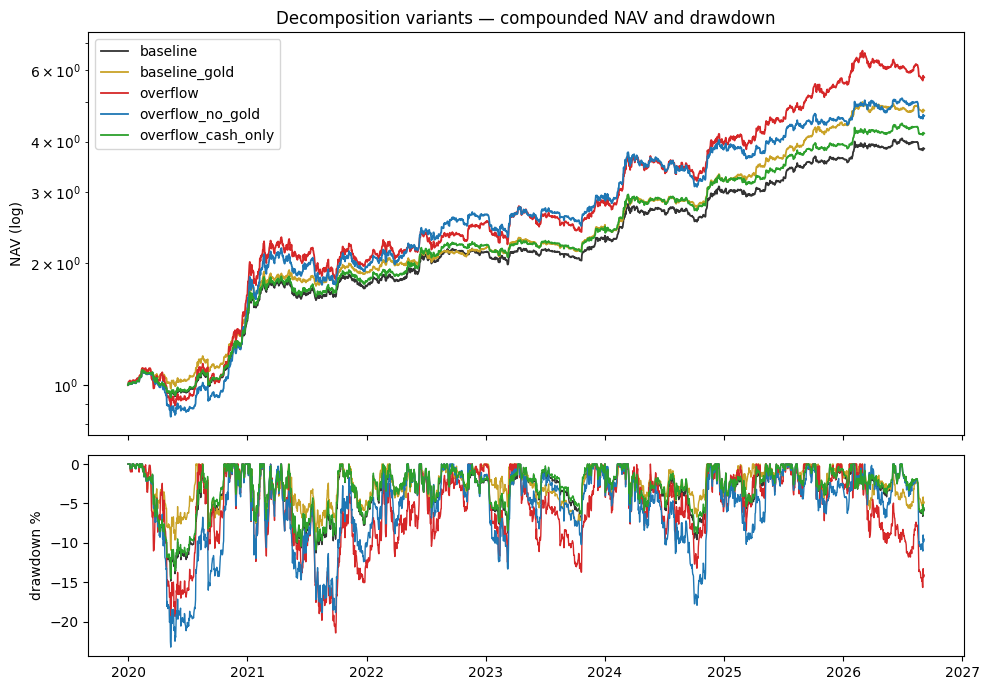

In [4]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
for name, color in (('baseline', '#333333'), ('baseline_gold', '#c9a227'), ('overflow', '#d62728'),
                    ('overflow_no_gold', '#1f77b4'), ('overflow_cash_only', '#2ca02c')):
    e = pd.read_csv(f'results/equity_{name}.csv', parse_dates=['date'])
    axes[0].plot(e.date, e.nav, label=name, color=color, lw=1.3)
    peak = np.maximum.accumulate(e.nav.values)
    axes[1].plot(e.date, (e.nav.values / peak - 1) * 100, color=color, lw=1.0)
axes[0].set_yscale('log'); axes[0].set_ylabel('NAV (log)'); axes[0].legend(loc='upper left')
axes[0].set_title('Decomposition variants — compounded NAV and drawdown')
axes[1].set_ylabel('drawdown %')
plt.tight_layout()


## 5. Where the capital sits (overflow variant)

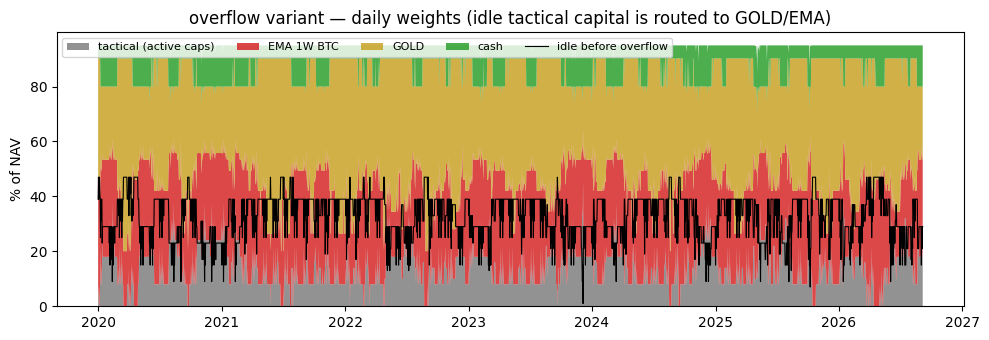

In [5]:
e = pd.read_csv('results/equity_overflow.csv', parse_dates=['date'])
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.stackplot(e.date, e.w_tactical * 100, e.w_ema * 100, e.w_gold * 100, e.w_cash * 100,
             labels=['tactical (active caps)', 'EMA 1W BTC', 'GOLD', 'cash'],
             colors=['#7f7f7f', '#d62728', '#c9a227', '#2ca02c'], alpha=0.85)
ax.plot(e.date, e.idle * 100, color='k', lw=0.8, label='idle before overflow')
ax.set_ylabel('% of NAV'); ax.legend(loc='upper left', ncol=5, fontsize=8)
ax.set_title('overflow variant — daily weights (idle tactical capital is routed to GOLD/EMA)')
plt.tight_layout()


## 6. Attribution, per-year returns, paired bootstrap of ΔSharpe (diagnostic)

In [6]:
sc = pd.read_csv('results/sleeve_contrib.csv')
piv = sc.pivot(index='sleeve', columns='variant', values='sum_contrib_pct')
display(piv[['baseline', 'baseline_gold', 'overflow', 'overflow_no_gold', 'overflow_cash_only']].round(1))
py = pd.read_csv('results/per_year.csv', index_col=0)
display((py * 100).round(1))
bb = pd.read_csv('results/bootstrap_delta.csv')
display(bb[['a', 'b', 'point', 'p05', 'p50', 'p95', 'p_gt_0', 'p_ge_010', 'p_ge_020']].round(3))


variant,baseline,baseline_gold,overflow,overflow_no_gold,overflow_cash_only
sleeve,,,,,
adx,28.4,28.4,28.0,28.0,28.4
carry,5.9,5.9,5.9,5.9,5.9
cash,8.0,2.4,2.4,2.4,16.8
chento_btc,1.2,1.2,1.2,1.2,1.2
chento_eth,1.9,1.9,1.9,1.9,1.9
ema_1w_btc,41.2,41.6,74.3,74.3,41.2
eth_daily,10.7,10.7,10.7,10.7,10.7
gold,0.0,32.4,49.3,10.9,0.0
r4_btc,4.6,4.6,4.4,4.4,4.6


,2020,2021,2022,2023,2024,2025,2026
variant,,,,,,,
baseline,43.9,22.6,21.0,7.6,30.3,21.7,5.5
baseline_gold,54.9,23.1,14.2,12.1,31.0,37.4,8.6
overflow,67.0,22.1,23.9,11.6,40.1,41.8,2.9
overflow_no_gold,52.6,28.7,34.6,9.6,32.3,19.2,1.4
overflow_cash_only,45.7,24.3,22.6,9.0,32.0,23.3,6.4
overflow_split40_60_gross1.5x,57.3,12.0,24.4,11.2,44.5,40.2,4.9
overflow_split40_60_gross2x,57.3,12.0,24.4,11.2,44.5,40.2,4.9
overflow_split80_20_gross1.5x,64.8,17.1,15.3,12.7,42.1,52.0,6.5
overflow_split80_20_gross2x,64.8,17.1,15.3,12.7,42.1,52.0,6.5


,a,b,point,p05,p50,p95,p_gt_0,p_ge_010,p_ge_020
0,overflow,baseline,-0.228,-0.595,-0.219,0.142,0.164,0.076,0.030
1,overflow_no_gold,baseline,-0.323,-0.544,-0.309,-0.092,0.012,0.004,0.000
2,overflow_cash_only,baseline,0.114,0.104,0.115,0.126,1.000,0.992,0.000
3,baseline_gold,baseline,0.386,0.051,0.378,0.738,0.972,0.917,0.806
4,overflow,baseline_gold,-0.614,-0.856,-0.603,-0.343,0.000,0.000,0.000
